<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_breast_cancer
cancer_data = load_breast_cancer()
print("Breast cancer dataset loaded successfully.")

Breast cancer dataset loaded successfully.


## Prepare Data

### Subtask:
Separate the features (X) and the target variable (y) from the loaded dataset.


**Reasoning**:
Separate the features (X) and the target variable (y) from the `cancer_data` object by accessing its `.data` and `.target` attributes respectively. Then, print their shapes to confirm the separation.



In [ ]:
X = cancer_data.data
y = cancer_data.target

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (569, 30)
Shape of target (y): (569,)


## Standardize Features

### Subtask:
Apply StandardScaler to the features (X) to ensure all features contribute equally to the PCA.


**Reasoning**:
Import `StandardScaler` from `sklearn.preprocessing` and apply it to the features `X` to standardize them, storing the result in `X_scaled`.



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape of scaled features (X_scaled): {X_scaled.shape}")

Shape of scaled features (X_scaled): (569, 30)


## Apply PCA and Get Variance

### Subtask:
Apply Principal Component Analysis (PCA) to reduce the standardized features to 2 components. Additionally, calculate and display the explained variance ratio for these components.


**Reasoning**:
Import `PCA` from `sklearn.decomposition`, apply it to the scaled data `X_scaled` to reduce dimensions to 2, and then print the explained variance ratio for each component and the total explained variance.



In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape of PCA-transformed data (X_pca): {X_pca.shape}")
print(f"Explained variance ratio per component: {pca.explained_variance_ratio_}")
print(f"Total explained variance ratio: {pca.explained_variance_ratio_.sum()}")

Shape of PCA-transformed data (X_pca): (569, 2)
Explained variance ratio per component: [0.44272026 0.18971182]
Total explained variance ratio: 0.6324320765155944


## Generate Scatter Plot

### Subtask:
Create a scatter plot of the 2 PCA components, coloring the points based on the target variable (y) to visualize the data distribution in the reduced dimension. Ensure the plot includes a legend.


**Reasoning**:
To generate the scatter plot as requested, I need to use `matplotlib.pyplot`. The plot will display the two principal components, with points colored according to the target variable to visualize class separation. I will iterate through the unique target classes to assign distinct colors and legend labels.



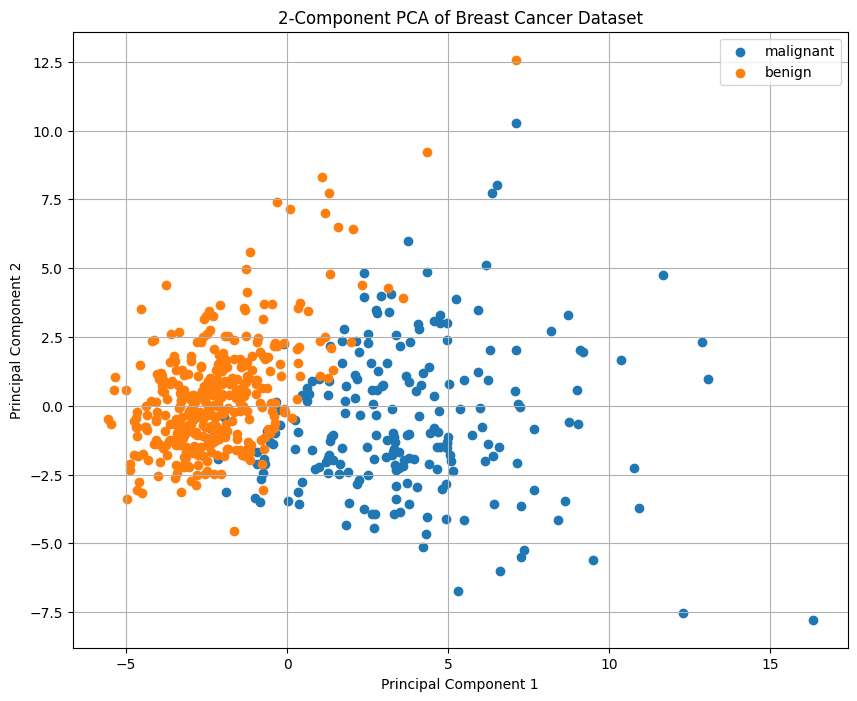

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

target_names = cancer_data.target_names

for i, target_name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0],
                X_pca[y == i, 1],
                label=target_name)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2-Component PCA of Breast Cancer Dataset')
plt.legend()
plt.grid(True)
plt.show()


## Summary of PCA Results

The PCA successfully reduced the dataset to 2 principal components. The explained variance ratio for Principal Component 1 is 0.4427, and for Principal Component 2 is 0.1897. Together, these two components explain approximately 63.24% of the total variance in the dataset. While this doesn't capture all the variance, it's a significant portion for a 2-component reduction.

### Patterns Observed in the Scatter Plot

The scatter plot of the two principal components shows a clear separation between the two target classes: 'malignant' and 'benign'.

*   **Malignant (blue dots)**: These points tend to cluster towards higher values on Principal Component 1, and show a wider spread along Principal Component 2.
*   **Benign (orange dots)**: These points are predominantly grouped in the lower values of Principal Component 1, indicating a distinct separation from the malignant class along this component.

The separation is visually distinct, suggesting that even with only two principal components, PCA effectively captures the underlying structure in the data that differentiates between malignant and benign breast cancer cells. This indicates that the original features, when projected onto these two principal components, allow for good discrimination between the two classes.

## Summary:

### Q&A
*   **Summary of PCA results, including explained variance:** The PCA successfully reduced the dataset to 2 principal components. Principal Component 1 explains 44.27% of the variance, and Principal Component 2 explains 18.97% of the variance. Together, these two components capture approximately 63.24% of the total variance in the original dataset.
*   **Patterns observed in the scatter plot regarding the separation of classes:** The scatter plot shows a clear separation between the 'malignant' and 'benign' classes. 'Malignant' points tend to cluster towards higher values on Principal Component 1, while 'benign' points are predominantly grouped in the lower values of Principal Component 1. This indicates that the first principal component is highly effective in discriminating between the two classes.

### Data Analysis Key Findings
*   The `breast_cancer` dataset contains 569 samples and 30 features.
*   After standardization, features were fed into PCA.
*   PCA successfully reduced the 30 features to 2 principal components.
*   The first principal component (PC1) explains 44.27% of the total variance.
*   The second principal component (PC2) explains 18.97% of the total variance.
*   Cumulatively, the two principal components explain 63.24% of the total variance in the dataset.
*   The scatter plot of the two principal components visually demonstrates a distinct separation between 'malignant' and 'benign' classes, primarily driven by differences along Principal Component 1.

### Insights or Next Steps
*   The clear separation of classes in the 2-component PCA space suggests that these two principal components could be highly effective features for a subsequent classification model.
*   Given that 63.24% variance is captured by just two components, further analysis could explore if adding a third principal component (if needed) significantly increases the explained variance to capture more nuanced patterns or improve model performance for predictive tasks.
